All reactions

In [256]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import k, e, pi

In [257]:

power_list = [50, 100, 200, 400, 600, 800, 1e3, 1160, 1.2e3, 1.4e3, 1.6e3]
#power_absorbed = []
Le=[]
LXe=[]
LXe_ion=[]
LTe=[]
LTXe=[]
L_thrust_ion =[]
L_thrust_neutral = []
L_thrust_total = []
Ji = []
L_uB = []
L_hL = []
L_Rind = []
L_pte = []
tracked_variables = {}
for i in range(len(power_list)):
    log_file_path = '../logs/all_reac_power_rf'+str(i)+'.json'
    print(log_file_path)
    with open(log_file_path, 'r') as file:
        tracked_variables = json.load(file)
    Le.append(tracked_variables["e_density"][-1])
    LXe.append(tracked_variables["Xe_density"][-1])
    LXe_ion.append(tracked_variables["Xe+_density"][-1])
    LTe.append(tracked_variables['temperature_0_atom'][-1])
    LTXe.append(tracked_variables['temperature_1_atom'][-1])
    L_thrust_ion.append(tracked_variables['total_ion_thrust'][-1])
    L_thrust_neutral.append(tracked_variables['total_neutral_thrust'][-1])
    L_thrust_total.append(tracked_variables['total_thrust'][-1])
    L_Rind.append(tracked_variables['R_ind'][-1])
    Ji.append(tracked_variables['ion_current'][-1])
    L_uB.append(tracked_variables['u_B'][-1])
    L_hL.append(tracked_variables['h_L'][-1])
    L_pte.append(tracked_variables["power_transfer_efficiency"][-1])


../logs/all_reac_power_rf0.json
../logs/all_reac_power_rf1.json
../logs/all_reac_power_rf2.json
../logs/all_reac_power_rf3.json
../logs/all_reac_power_rf4.json
../logs/all_reac_power_rf5.json
../logs/all_reac_power_rf6.json
../logs/all_reac_power_rf7.json
../logs/all_reac_power_rf8.json
../logs/all_reac_power_rf9.json
../logs/all_reac_power_rf10.json


In [258]:
zeta_list=[]
for r in L_Rind:
    zeta_list.append(r/(r+2))

#power_list_bis = []
# for i in range(len(power_absorbed)):
#     R_ind = power_absorbed[i] * 2 / coil_currents[i]**2
#     R_ind_list.append(R_ind)
#     zeta = R_ind / (R_ind + 2)
#     zeta_list.append(zeta)
#     power_list.append(power_absorbed[i]/zeta)
    #power_list_bis.append((R_ind + 2) * coil_currents[i]**2/2) #ça donne la même chose

# for i in range(len(LTe)):
#     power_list.append( 0.5 * (2*L_Rind[i]+2) * coil_currents[i]**2 )

# print(power_list)

In [259]:
print(L_Rind)

[9.710765123063702, 7.291861535828831, 5.087707674579885, 3.31205540343813, 2.485917992100975, 1.991312021119323, 1.6578560206333397, 1.4596380610064386, 1.4169575625810031, 1.2348702571484733, 1.0927301529308564]


In [260]:
print(power_list)

[50, 100, 200, 400, 600, 800, 1000.0, 1160, 1200.0, 1400.0, 1600.0]


In [261]:
gamma_list = []
Pi_list = []
Pn_list = []
gamma_i = []
V_grid = 1000
m_ion = 2.18e-25
v_beam = np.sqrt((2*e*V_grid)/m_ion)
vg_list = []
for i in range(len(power_list)):
    gamma_i.append(Ji[i]/e)
    #Pi_list.append(Ji[i]*1000*0.7*pi*(6e-2)**2)
    vg_list.append(np.sqrt(8*e*LTXe[i]/(pi*m_ion)))
    Pi_list.append(L_thrust_ion[i] * v_beam /2)
    Pn_list.append(L_thrust_neutral[i] * vg_list[i] / 2)
    gamma_list.append((Pi_list[i] + Pn_list[i])/(Pi_list[i] + Pn_list[i] + power_list[i]))
     

In [262]:
xi_list = []
for i in range(len(power_list)):
    xi_list.append((L_thrust_ion[i]+L_thrust_neutral[i])/power_list[i])

In [263]:
eta_list= []
for i in range(len(power_list)):
    eta=L_hL[i] * LXe_ion[i] * L_uB[i] * 0.7 * np.pi * (6e-2)**2 / 1.2e19
    eta_list.append(eta)

In [264]:
print(LXe)
print(len(Le))
print(len(power_list))

[5.44121482633841e+19, 5.026296778794515e+19, 4.391500348377972e+19, 3.5300610051883536e+19, 2.946069767831227e+19, 2.514517685056031e+19, 2.1807125946772926e+19, 1.963870802224248e+19, 1.9152835911767495e+19, 1.7002293085389193e+19, 1.52349374782244e+19]
11
11


1.4596380610064386


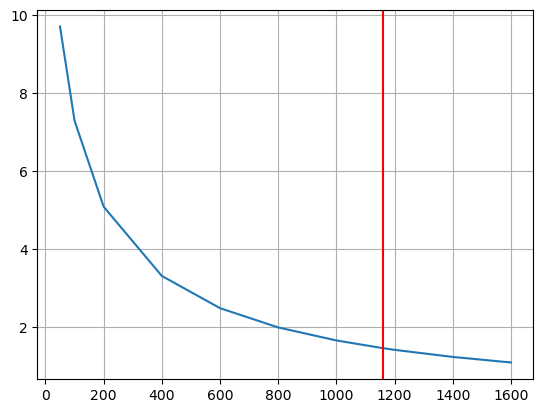

In [ ]:
plt.plot(power_list,L_Rind)
plt.grid()
x_vert_bis = 1160
plt.axvline(x_vert_bis, color = 'r')
print(L_Rind[7]) #1.46

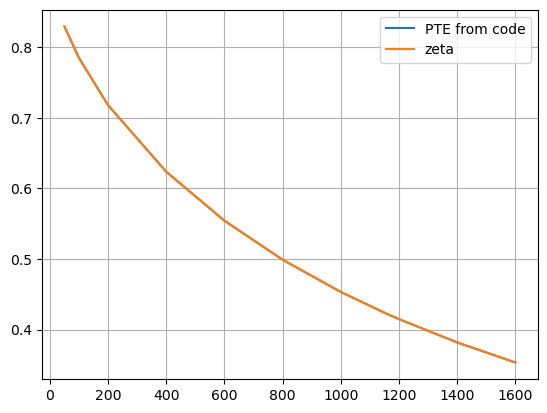

In [265]:
plt.plot(power_list, L_pte, label = "PTE from code")
plt.plot(power_list, zeta_list, label = "zeta")
plt.legend()
plt.grid()
plt.show()

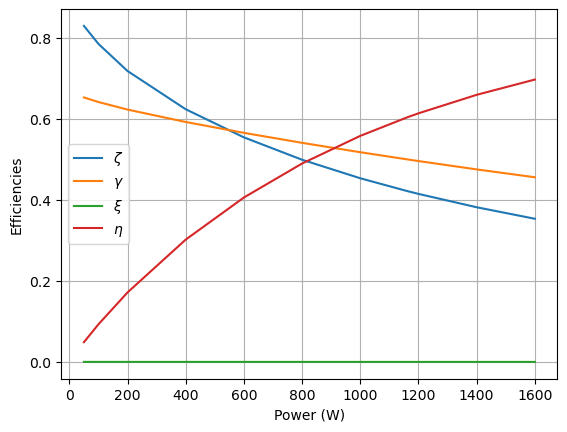

In [266]:
plt.plot(power_list, zeta_list, label = r"$\zeta$")
plt.plot(power_list, gamma_list, label = r"$\gamma$")
plt.plot(power_list, xi_list, label = r"$\xi$")
plt.plot(power_list, eta_list, label = r"$\eta$")
plt.xlabel("Power (W)")
plt.ylabel("Efficiencies")
plt.legend()
plt.grid()

146.51138415913462


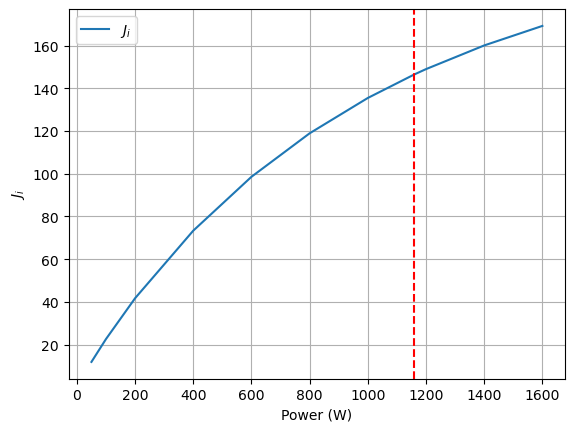

In [267]:
plt.plot(power_list, Ji, label = r"$J_{i}$")
x_vert=1160
plt.axvline(x_vert, color='r', linestyle='--')
plt.xlabel("Power (W)")
plt.ylabel(r"$J_{i}$")
plt.grid()
plt.legend()
print(Ji[7])

C:\Users\verdi\AppData\Local\Temp\ipykernel_9356\1114187649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


1.4812219685380004e+18
1.52349374782244e+19


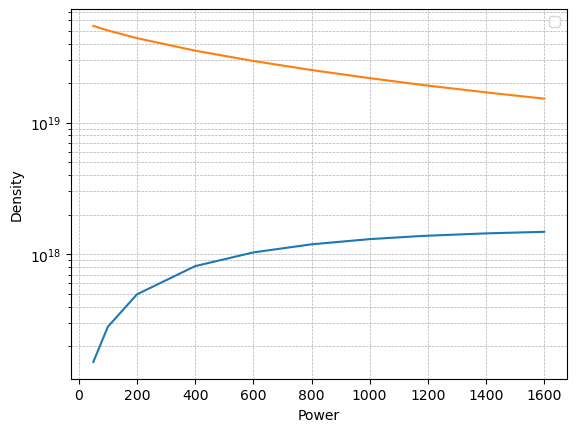

In [268]:
from matplotlib.ticker import LogLocator

x=power_list
y=Le
z=LXe

fig, ax = plt.subplots()
ax.plot(x,y)
ax.plot(x,z)

ax.set_yscale('log')

ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0, ), numticks=10))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# plt.plot(x, y, label="electron density")
# plt.grid()
# plt.yscale('log')
plt.xlabel("Power")
plt.ylabel("Density")
plt.legend()

print(Le[-1])
print(LXe[-1])

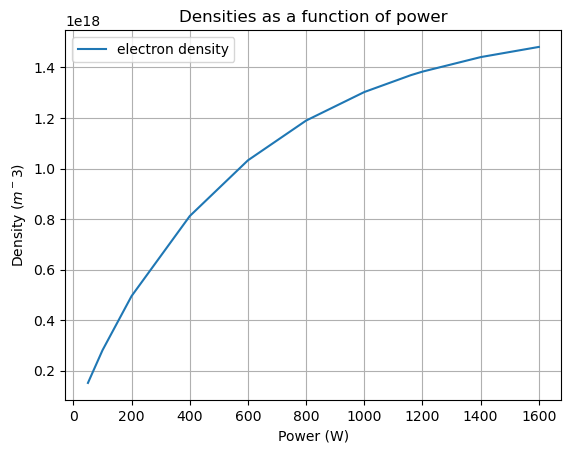

In [269]:
plt.plot(x, y, label="electron density")
plt.grid()
plt.xlabel("Power (W)")
plt.ylabel(f"Density ($m^{-3}$)")
plt.title("Densities as a function of power")
plt.legend()

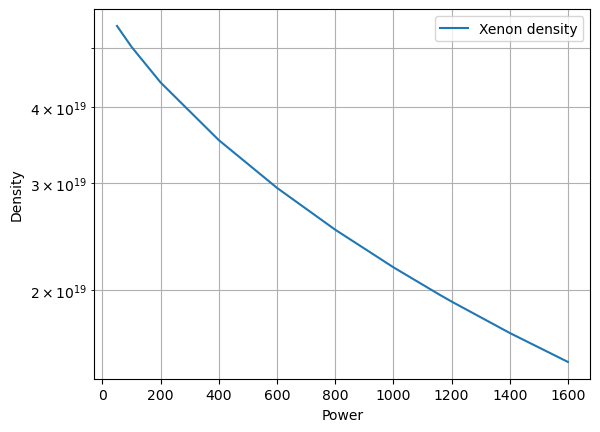

In [270]:
plt.plot(x, LXe, label="Xenon density")
plt.grid(True, which='both')
plt.yscale('log')
plt.xlabel("Power")
plt.ylabel("Density")
plt.legend()

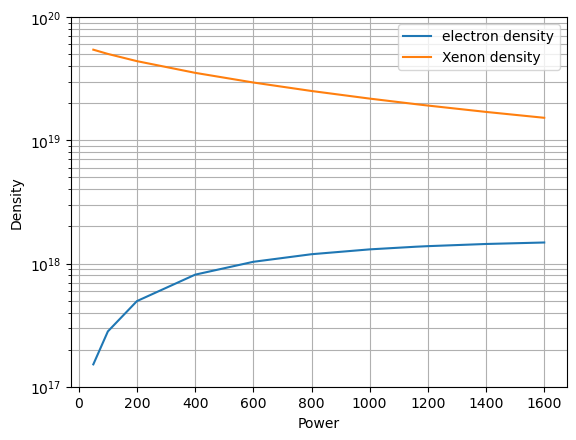

In [271]:
plt.plot(x, y, label="electron density")
plt.plot(x, LXe, label="Xenon density")
plt.ylim(1e17, 1e20)
plt.grid(True, which='both')
plt.yscale('log')
plt.xlabel("Power")
plt.ylabel("Density")
plt.legend()

In [272]:
from scipy.constants import k, e, pi
import matplotlib.pyplot as plt

def plot_variables(var_list1, var_list2):
    """
    Plots the evolution of variables from tracked_variables with 'time' on the x-axis.
    The first list of variables is plotted on the primary y-axis, and the second list on a secondary y-axis.

    Parameters:
    var_list1 (list): List of variable names to plot on the primary y-axis.
    var_list2 (list): List of variable names to plot on the secondary y-axis.
    """
    
    fig, ax1 = plt.subplots()

    # Plot variables from var_list1 on the primary y-axis
    ax1.plot(power_list, var_list1, label="electron temperature")
    ax1.set_xlabel('Power')
    ax1.set_ylim(2.4, 5)
    ax1.set_ylabel('Electron temperature')
    ax1.grid()

    # #Vérification du temps de relaxation:
    # tau=7.9e-3
    # T_init=3
    # L=[tangente(t,T_init,tau) for t in time]

    # Create a secondary y-axis
    L=[v*e/k for v in var_list2]
    ax2 = ax1.twinx()
    ax2.plot(power_list, L, 'g', label="Xenon temperature")
    # ax2.plot(L,label="tangente à l'orgine")
    ax2.set_ylabel('Xenon Temperature (K)')

    ax2.legend(loc='best')

    # x_vert=7.9e-3
    # plt.axvline(x_vert, color='r', linestyle='--')

    lines_2, labels_2 = ax2.get_legend_handles_labels()
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    ax2.legend(lines_2 + lines_1, labels_2 + labels_1, loc='best')

    plt.title('Evolution of Variables')
    plt.show()

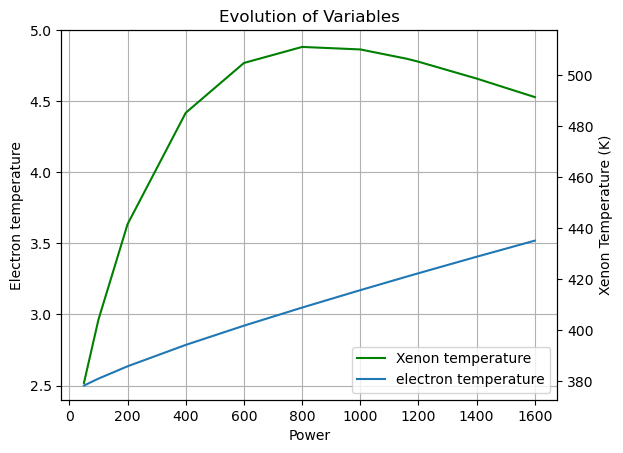

491.3368474577057


In [273]:
plot_variables(LTe,LTXe)
print(LTXe[-1]*e/k)

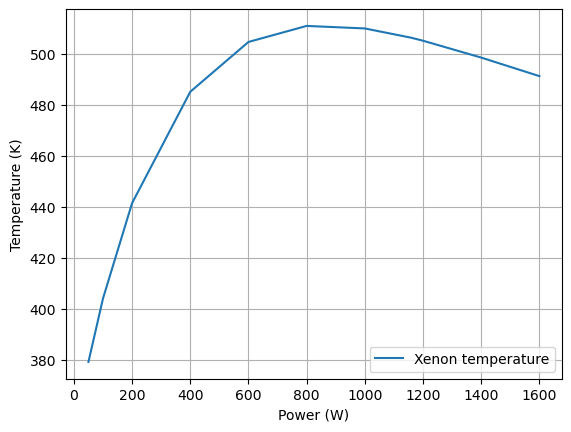

In [274]:
#plt.plot(power_list,LTe, label="electron temperature")
L=[v*e/k for v in LTXe]
plt.plot(power_list,L, label="Xenon temperature")
plt.grid()
plt.xlabel("Power (W)")
plt.ylabel("Temperature (K)")
plt.legend()

3.5192381536604156


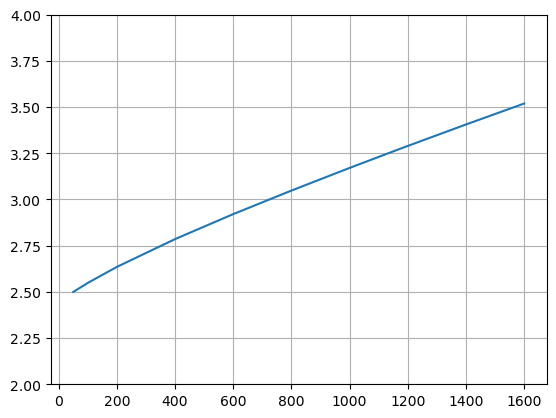

In [275]:
plt.plot(power_list, LTe)
plt.grid()
plt.ylim(2, 4)
print(LTe[-1])

- Max des Températures du Xénon: 505 K, ce qui est un peu bas (plutôt proche du 520 K)
- Min des Températures du Xénon: 347 K, ce qui est un peu haut (plutôt proche du 300 K)

Températures finales de l'électron:
- plus de 3.5 eV ce qui est un peu haut
- le min a l'air cohérent

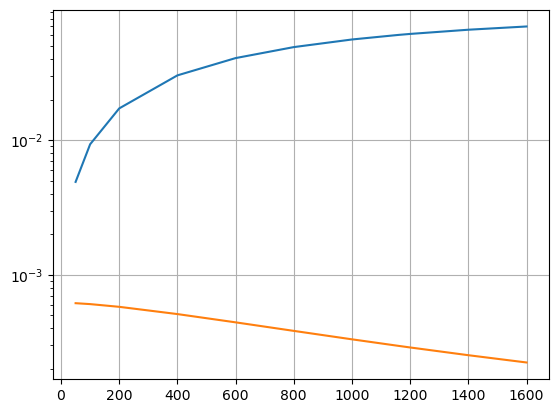

In [276]:
plt.plot(power_list, L_thrust_ion, label = "ion thrust")
plt.plot(power_list, L_thrust_neutral, label = "neutral thrust")
plt.yscale("log")
plt.grid()

In [277]:
print(LTXe)
print(LTe)

[0.03267872136465882, 0.03482405492576351, 0.03804625614607213, 0.041811007153036026, 0.043494525073803296, 0.044036736438771894, 0.04395150928210584, 0.043636453970368694, 0.04353681313879028, 0.042966518329030395, 0.04234013358514839]
[2.4997109037496883, 2.548583298590445, 2.6352761866688015, 2.7856616105739884, 2.920857239561263, 3.0482355341513254, 3.1707912687183972, 3.266266361470358, 3.2898244171042292, 3.4058940219885967, 3.5192381536604156]


ValueError: x and y must have same first dimension, but have shapes (11,) and (3,)

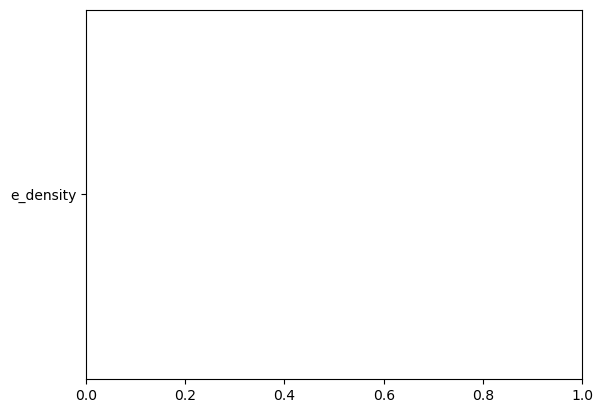

In [278]:
plot_variables(['e_density','Xe_density', 'Xe+_density'], [])
plot_variables(['e_density'], ['Xe_density'])
plot_variables(['dy_e_density'], ['dy_Xe_density', 'dy_Xe+_density'])
plot_variables(['Xe+_density'],[])
plot_variables(['e_density'],[])

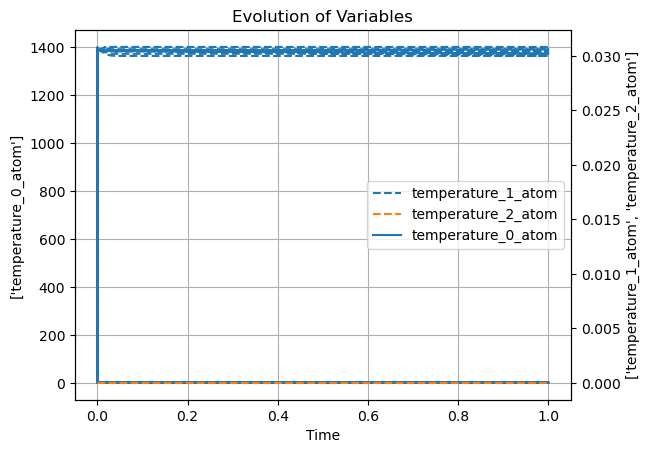

C:\Users\verdi\AppData\Local\Temp\ipykernel_20032\1856211196.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='best')


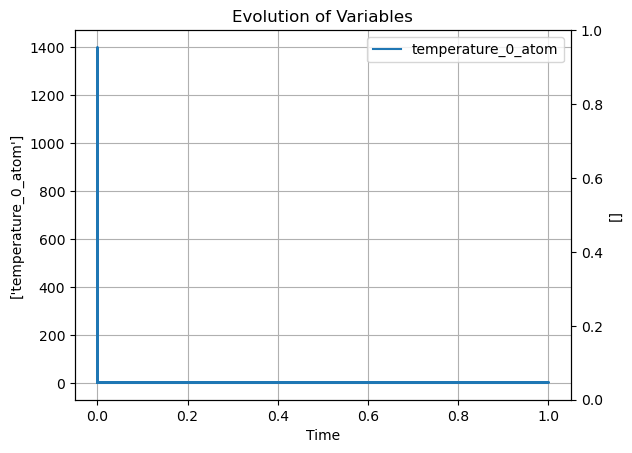

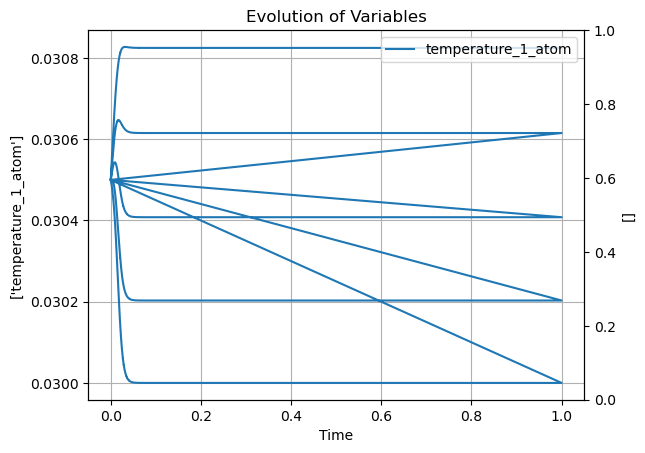

In [ ]:
plot_variables(["temperature_0_atom"], ["temperature_1_atom", "temperature_2_atom"])
#plot_variables(["dy_temperature_0_atom"], ["dy_temperature_1_atom", "dy_temperature_2_atom"])
plot_variables(["temperature_0_atom"],[])
plot_variables(["temperature_1_atom"],[])


Asymptote horizontale à la température des électrons = 0.054 eV d'après la simu json. Donc cohérent avec valeur théorique.

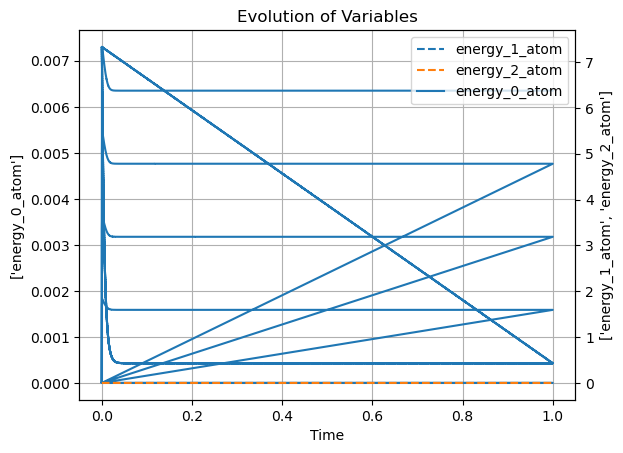

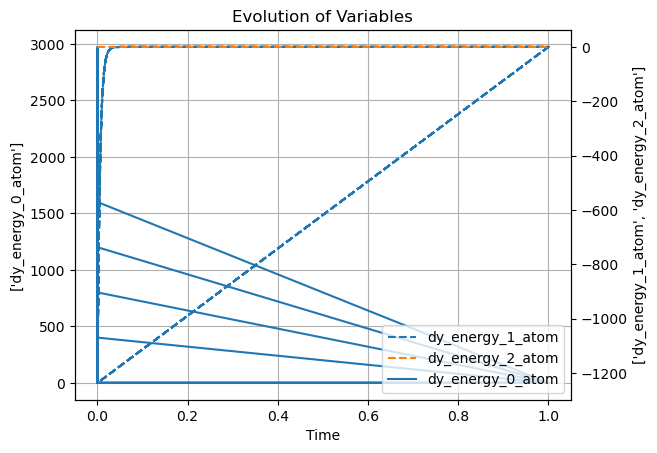

In [ ]:
plot_variables(['energy_0_atom'], ['energy_1_atom', 'energy_2_atom'])
plot_variables(['dy_energy_0_atom'], ['dy_energy_1_atom', 'dy_energy_2_atom'])

C:\Users\verdi\AppData\Local\Temp\ipykernel_20032\1856211196.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='best')


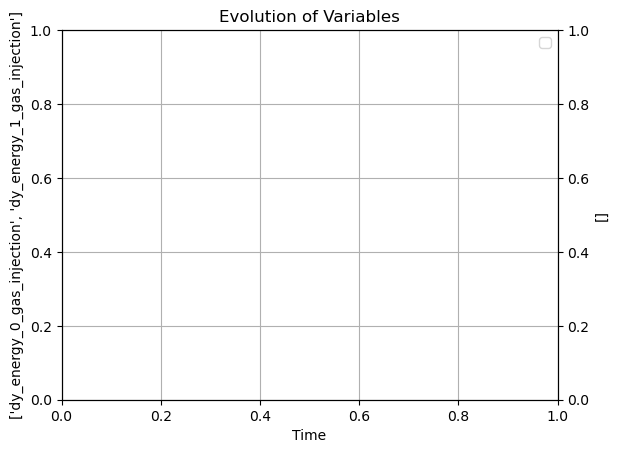

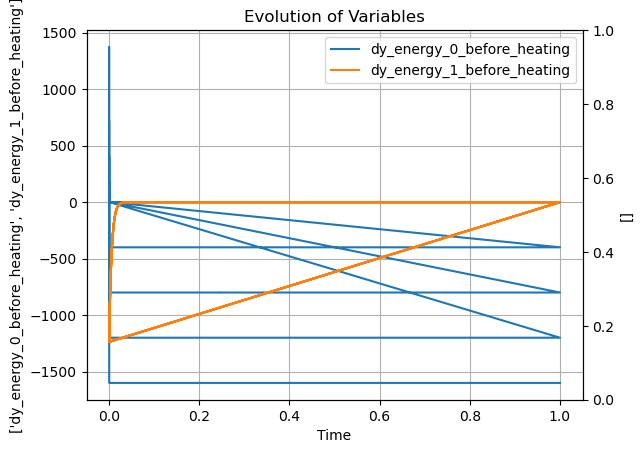

In [ ]:
plot_variables(['dy_energy_0_gas_injection', 'dy_energy_1_gas_injection'], [])
plot_variables(['dy_energy_0_before_heating', 'dy_energy_1_before_heating'], [])

C:\Users\verdi\AppData\Local\Temp\ipykernel_20032\1856211196.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='best')


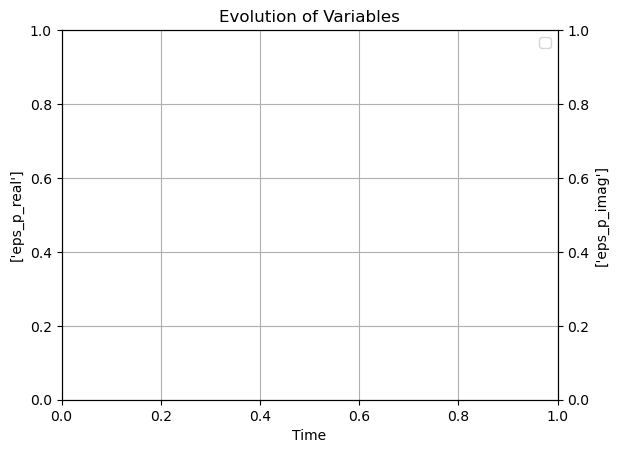

In [ ]:
plot_variables(["eps_p_real"], ["eps_p_imag"])

C:\Users\verdi\AppData\Local\Temp\ipykernel_20032\1856211196.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='best')


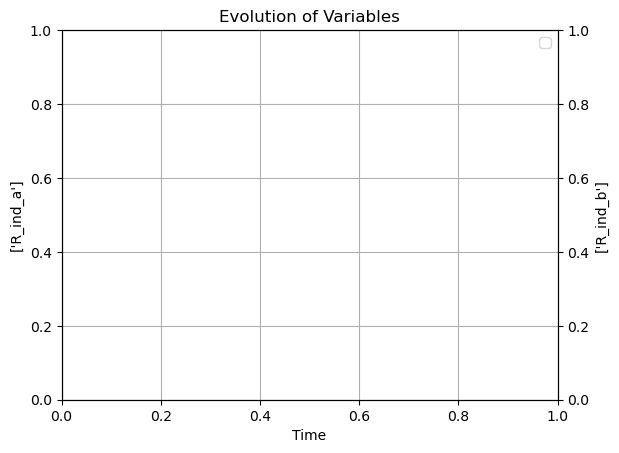

In [ ]:
plot_variables(["R_ind_a"], ["R_ind_b"])

C:\Users\verdi\AppData\Local\Temp\ipykernel_20032\1856211196.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='best')


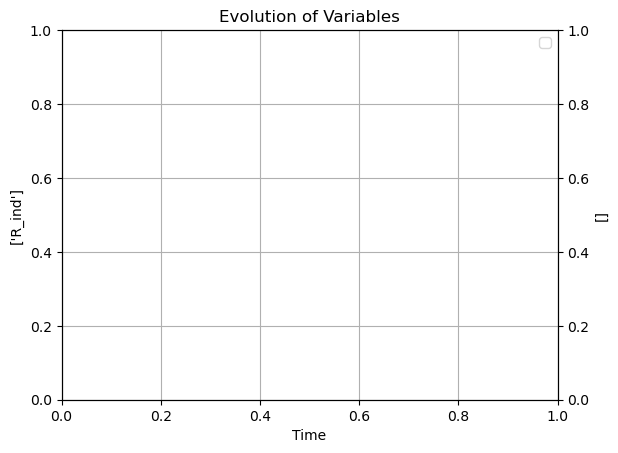

In [ ]:
plot_variables(["R_ind"], [])